# BERT Finetuning for IMDB Sentiment Analysis — Main Notebook


In [1]:
# Setup and imports
import sys
sys.path.append('../src')

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Our helper files
from tokenizer import BERTTokenizer, create_dataloaders
from model import BERTSentimentClassifier, BaselineLSTM, BaselineMLP
from trainer import Trainer

np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Configuration

In [2]:
BATCH_SIZE = 16
MAX_LENGTH = 256  # max tokens per example 
EPOCHS_BERT = 3  
EPOCHS_BASELINE = 5
PARTIAL_UNFREEZE_LAYERS = 2  # partial BERT fine-tuning train only the last N transformer layers
LEARNING_RATE_BERT = 2e-5
LEARNING_RATE_BASELINE = 1e-3
RESULTS_DIR = '../results'

# - Batch size: 16, we decided to not use 32 because of GPU memory constraints 
# - Learning rate: around 2e-5 to 5e-5
# - Epochs: 2 to 4, since BERT can overfit quickly

## 1) Data loading & Exploratory Data Analysis (EDA)

Purpose: load the IMDb dataset, inspect class balance, sample texts and text-length statistics.

Notes:
- The dataset is loaded from HuggingFace with `load_dataset("imdb")`.
- The plots are shown inline so the reader can follow the data story right away.

In [3]:
# Load IMDb
dataset = load_dataset('imdb')
train_data = dataset['train']
test_data = dataset['test']

In [4]:
# Basic dataset info
print('IMDb Dataset Info')
print(f'Number of training examples: {len(train_data)}')
print(f'Number of test examples: {len(test_data)}')

train_labels = train_data['label']
test_labels = test_data['label']

print('\nTraining set class distribution:')
print(Counter(train_labels))

print('\nTest set class distribution:')
print(Counter(test_labels))

IMDb Dataset Info
Number of training examples: 25000
Number of test examples: 25000

Training set class distribution:
Counter({0: 12500, 1: 12500})

Test set class distribution:
Counter({0: 12500, 1: 12500})


In [5]:
# Print a few sample reviews
n_samples = 3
print(f'Sample Reviews (n={n_samples})')

for i in range(n_samples):
    text = train_data['text'][i]
    label = train_data['label'][i]
    sentiment = 'Positive' if label == 1 else 'Negative'
    print(f'\nReview {i + 1} ({sentiment}):\n{text[:500]}...')

Sample Reviews (n=3)

Review 1 (Negative):
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent...

Review 2 (Negative):
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping labia? Nowhere, bec

In [6]:
# Text length analysis
lengths = [len(text.split()) for text in train_data['text']]

print('Text Length Analysis')
print(f'Average words per review: {np.mean(lengths):.1f}')
print(f'Median words per review: {np.median(lengths):.1f}')
print(f'Min words: {np.min(lengths)}')
print(f'Max words: {np.max(lengths)}')
print(f'95th percentile: {np.percentile(lengths, 95):.0f}')
print(f'Number of reviews analyzed: {len(lengths)}')

Text Length Analysis
Average words per review: 233.8
Median words per review: 174.0
Min words: 10
Max words: 2470
95th percentile: 598
Number of reviews analyzed: 25000


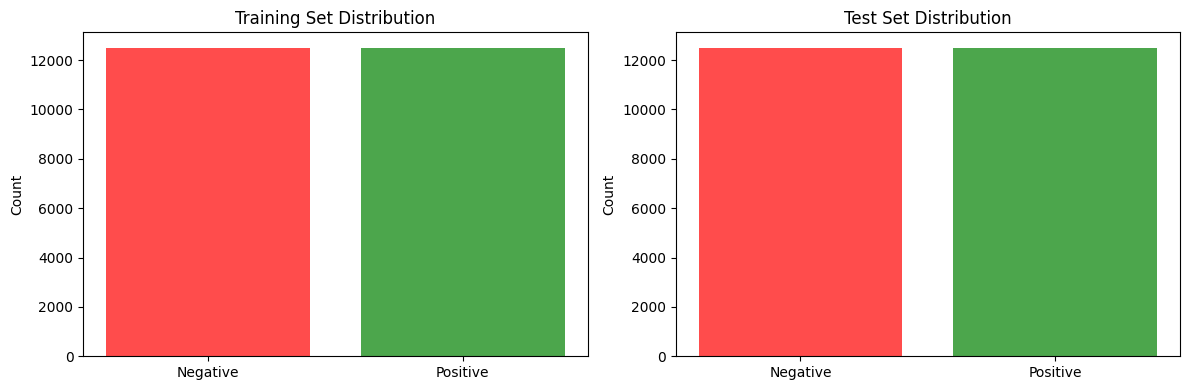

In [7]:
# Class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_labels = train_data['label']
train_counts = [train_labels.count(0), train_labels.count(1)]
axes[0].bar(['Negative', 'Positive'], train_counts, color=['red', 'green'], alpha=0.7)
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Count')

test_labels = test_data['label']
test_counts = [test_labels.count(0), test_labels.count(1)]
axes[1].bar(['Negative', 'Positive'], test_counts, color=['red', 'green'], alpha=0.7)
axes[1].set_title('Test Set Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

C:\Users\anton\AppData\Local\Temp\ipykernel_21596\692325909.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


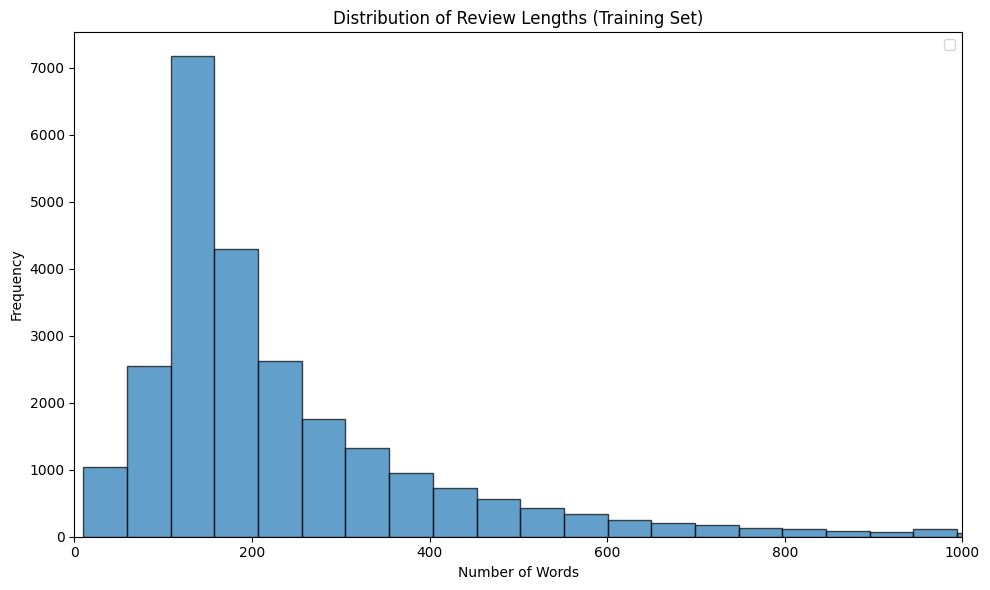

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths (Training Set)')
plt.legend()
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

## 2) Tokenization & DataLoaders

In [9]:
# Tokenizer and PyTorch loaders

tokenizer = BERTTokenizer()
train_texts, val_texts, train_labels, val_labels = train_test_split(
    list(train_data['text']),
    list(train_data['label']),
    test_size=0.1,
    random_state=42,
    stratify=list(train_data['label'])
)
test_texts = test_data['text']
test_labels = test_data['label']

# This function is in tokenizer.py
train_loader, val_loader, test_loader = create_dataloaders(
    train_texts, train_labels, val_texts, val_labels,
    test_texts, test_labels, tokenizer, batch_size=BATCH_SIZE, max_length=MAX_LENGTH
)

Vocabulary size: 30522
DataLoaders created:
  Training samples: 22500 (1407 batches)
  Validation samples: 2500 (157 batches)
  Test samples: 25000 (1563 batches)
  Batch size: 16
  Max sequence length: 256


## 3) Models & Training

This section trains five models for comparison:
- `BERT Fine-tuned`: full fine-tuning of `bert-base-uncased`.
- `BERT Partial`: mostly frozen BERT with only the last transformer layers fine-tuned.
- `BERT Frozen`: BERT used as a frozen feature extractor with a small head.
- `LSTM` and `MLP` baselines: quick, lightweight neural baselines trained from scratch.
- `TF-IDF + Logistic Regression`: a classical bag-of-words baseline.

In [10]:
'''
# Grid Search

# Define hyperparameter grid
learning_rates = [1e-5, 2e-5, 3e-5]
epochs_options = [2, 3, 4]
batch_sizes = [16]

# Store results
grid_results = []

for lr in learning_rates:
    for epochs in epochs_options:
        for batch_size in batch_sizes:
            print(f"Training: LR={lr}, EPOCHS={epochs}, BATCH_SIZE={batch_size}")

            # Recreate dataloaders with new batch size
            train_loader_gs, val_loader_gs, test_loader_gs = create_dataloaders(
                train_texts, train_labels, val_texts, val_labels,
                test_texts, test_labels, tokenizer, batch_size=batch_size, max_length=MAX_LENGTH
            )

            # Create and train model
            model_gs = BERTSentimentClassifier(freeze_bert=False)
            trainer_gs = Trainer(
                model_gs,
                train_loader_gs,
                val_loader_gs,
                test_loader_gs,
                device,
                lr,
                RESULTS_DIR,
                save_artifacts=False
            )

            # Train
            trainer_gs.train(epochs)

            # Evaluate on validation and test sets
            val_loss, val_accuracy, val_f1, _, _ = trainer_gs.evaluate(val_loader_gs)
            test_metrics = trainer_gs.evaluate_test(plot_confusion_matrix=False)

            # Store results
            grid_results.append({
                'learning_rate': lr,
                'epochs': epochs,
                'batch_size': batch_size,
                'val_accuracy': val_accuracy,
                'val_f1': val_f1,
                'test_accuracy': test_metrics['accuracy'],
                'test_f1': test_metrics['f1']
            })

            print(f"Val F1: {val_f1:.4f} | Test F1: {test_metrics['f1']:.4f}\n")

# Convert to DataFrame
grid_results_df = pd.DataFrame(grid_results)

# Show results directly in the notebook
print("Grid Search Results (sorted by validation F1)")
print(grid_results_df.sort_values('val_f1', ascending=False).to_string(index=False))

# Find best configuration
best_idx = grid_results_df['val_f1'].idxmax()
best_config = grid_results_df.loc[best_idx]

print("Best results")
print(f"Learning Rate: {best_config['learning_rate']}")
print(f"Epochs: {best_config['epochs']}")
print(f"Batch Size: {best_config['batch_size']}")
print(f"Validation F1: {best_config['val_f1']:.4f}")
print(f"Test F1: {best_config['test_f1']:.4f}")

'''

'\n# Grid Search\n\n# Define hyperparameter grid\nlearning_rates = [1e-5, 2e-5, 3e-5]\nepochs_options = [2, 3, 4]\nbatch_sizes = [16]\n\n# Store results\ngrid_results = []\n\nfor lr in learning_rates:\n    for epochs in epochs_options:\n        for batch_size in batch_sizes:\n            print(f"Training: LR={lr}, EPOCHS={epochs}, BATCH_SIZE={batch_size}")\n\n            # Recreate dataloaders with new batch size\n            train_loader_gs, val_loader_gs, test_loader_gs = create_dataloaders(\n                train_texts, train_labels, val_texts, val_labels,\n                test_texts, test_labels, tokenizer, batch_size=batch_size, max_length=MAX_LENGTH\n            )\n\n            # Create and train model\n            model_gs = BERTSentimentClassifier(freeze_bert=False)\n            trainer_gs = Trainer(\n                model_gs,\n                train_loader_gs,\n                val_loader_gs,\n                test_loader_gs,\n                device,\n                lr,\n      

In [11]:
#best option
EPOCHS_BERT = 4
LEARNING_RATE_BERT = 3e-5

BERT FINE TUNED

In [12]:
# Full BERT fine-tuning
print('Training BERT (fine-tuned)')
model_bert = BERTSentimentClassifier(freeze_bert=False)
trainer_bert = Trainer(model_bert, train_loader, val_loader, test_loader, device, LEARNING_RATE_BERT, f'{RESULTS_DIR}/bert_finetuned')
trainer_bert.train(EPOCHS_BERT, save_best=True, best_metric='val_f1')
trainer_bert.load_checkpoint()
bert_results = trainer_bert.evaluate_test()

Training BERT (fine-tuned)

Epoch 1/4


Training: 100%|██████████| 1407/1407 [08:42<00:00,  2.69it/s]


Train Loss: 0.2930, Acc: 0.8798
Val Loss: 0.2565, Acc: 0.9100, F1: 0.9100
Saved checkpoint to ../results/bert_finetuned/best_model.pt

Epoch 2/4


Training: 100%|██████████| 1407/1407 [08:43<00:00,  2.69it/s]


Train Loss: 0.1792, Acc: 0.9425
Val Loss: 0.2940, Acc: 0.9140, F1: 0.9140
Saved checkpoint to ../results/bert_finetuned/best_model.pt

Epoch 3/4


Training: 100%|██████████| 1407/1407 [09:03<00:00,  2.59it/s]


Train Loss: 0.1123, Acc: 0.9709
Val Loss: 0.4036, Acc: 0.9080, F1: 0.9080

Epoch 4/4


Training: 100%|██████████| 1407/1407 [09:15<00:00,  2.53it/s]


Train Loss: 0.0714, Acc: 0.9829
Val Loss: 0.4601, Acc: 0.9072, F1: 0.9071
Loaded checkpoint from epoch 2 with val acc 0.9140, val F1 0.9140 (selected by val_f1)

Test Accuracy: 0.9152
Test F1 Score: 0.9152

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.92      0.92     12500
    Positive       0.92      0.91      0.91     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



BERT FROZEN

In [13]:
# BERT frozen
print('Training BERT (frozen)')
model_frozen = BERTSentimentClassifier(freeze_bert=True)
trainer_frozen = Trainer(model_frozen, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/bert_frozen')
trainer_frozen.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_frozen.load_checkpoint()
frozen_results = trainer_frozen.evaluate_test()

Training BERT (frozen)

Epoch 1/5


Training: 100%|██████████| 1407/1407 [03:24<00:00,  6.87it/s]


Train Loss: 0.5689, Acc: 0.7042
Val Loss: 0.4886, Acc: 0.7788, F1: 0.7770
Saved checkpoint to ../results/bert_frozen/best_model.pt

Epoch 2/5


Training: 100%|██████████| 1407/1407 [03:24<00:00,  6.87it/s]


Train Loss: 0.5187, Acc: 0.7422
Val Loss: 0.4617, Acc: 0.7856, F1: 0.7846
Saved checkpoint to ../results/bert_frozen/best_model.pt

Epoch 3/5


...

Train Loss: 0.5029, Acc: 0.7562
Val Loss: 0.4407, Acc: 0.8036, F1: 0.8034
Saved checkpoint to ../results/bert_frozen/best_model.pt

Epoch 4/5


Training: 100%|██████████| 1407/1407 [03:24<00:00,  6.87it/s]


Train Loss: 0.4985, Acc: 0.7604
Val Loss: 0.4432, Acc: 0.8012, F1: 0.8012

Epoch 5/5


Training: 100%|██████████| 1407/1407 [03:25<00:00,  6.83it/s]


Train Loss: 0.5005, Acc: 0.7587
Val Loss: 0.4291, Acc: 0.8076, F1: 0.8076
Saved checkpoint to ../results/bert_frozen/best_model.pt
Loaded checkpoint from epoch 5 with val acc 0.8076, val F1 0.8076 (selected by val_f1)

Test Accuracy: 0.8051
Test F1 Score: 0.8051

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80     12500
    Positive       0.80      0.81      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000



BERT PART FROZEN

In [14]:
# Partial fine-tuning: only the last BERT layers are trainable
print(f'Training BERT (last {PARTIAL_UNFREEZE_LAYERS} layers fine-tuned)')
model_partial = BERTSentimentClassifier(freeze_bert=True)
model_partial.unfreeze_layers(PARTIAL_UNFREEZE_LAYERS)

trainable_params = sum(p.numel() for p in model_partial.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_partial.parameters())
print(f'Trainable parameters: {trainable_params:,} / {total_params:,}')

trainer_partial = Trainer(model_partial, train_loader, val_loader, test_loader, device, LEARNING_RATE_BERT, f'{RESULTS_DIR}/bert_partial')
trainer_partial.train(EPOCHS_BERT, save_best=True, best_metric='val_f1')
trainer_partial.load_checkpoint()
partial_results = trainer_partial.evaluate_test()

Training BERT (last 2 layers fine-tuned)
Trainable parameters: 14,767,874 / 109,483,778

Epoch 1/4


Training: 100%|██████████| 1407/1407 [04:17<00:00,  5.47it/s]


Train Loss: 0.3031, Acc: 0.8730
Val Loss: 0.2645, Acc: 0.8976, F1: 0.8974
Saved checkpoint to ../results/bert_partial/best_model.pt

Epoch 2/4


Training: 100%|██████████| 1407/1407 [04:15<00:00,  5.50it/s]


Train Loss: 0.2414, Acc: 0.9059
Val Loss: 0.2620, Acc: 0.9064, F1: 0.9063
Saved checkpoint to ../results/bert_partial/best_model.pt

Epoch 3/4


Training: 100%|██████████| 1407/1407 [04:12<00:00,  5.56it/s]


Train Loss: 0.2119, Acc: 0.9212
Val Loss: 0.2533, Acc: 0.9084, F1: 0.9084
Saved checkpoint to ../results/bert_partial/best_model.pt

Epoch 4/4


Training: 100%|██████████| 1407/1407 [04:21<00:00,  5.38it/s]


Train Loss: 0.1811, Acc: 0.9355
Val Loss: 0.2781, Acc: 0.9104, F1: 0.9104
Saved checkpoint to ../results/bert_partial/best_model.pt
Loaded checkpoint from epoch 4 with val acc 0.9104, val F1 0.9104 (selected by val_f1)

Test Accuracy: 0.9137
Test F1 Score: 0.9137

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.91      0.91     12500
    Positive       0.91      0.92      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.91      0.91      0.91     25000
weighted avg       0.91      0.91      0.91     25000



LSTM BASELINE

In [15]:
# LSTM baseline
print('Training LSTM baseline')
model_lstm = BaselineLSTM(vocab_size=tokenizer.vocab_size)
trainer_lstm = Trainer(model_lstm, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/lstm')
trainer_lstm.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_lstm.load_checkpoint()
lstm_results = trainer_lstm.evaluate_test()

Training LSTM baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [02:04<00:00, 11.34it/s]


Train Loss: 0.6385, Acc: 0.6213
Val Loss: 0.4739, Acc: 0.7848, F1: 0.7823
Saved checkpoint to ../results/lstm/best_model.pt

Epoch 2/5


Training: 100%|██████████| 1407/1407 [02:04<00:00, 11.30it/s]


Train Loss: 0.3916, Acc: 0.8328
Val Loss: 0.3524, Acc: 0.8512, F1: 0.8511
Saved checkpoint to ../results/lstm/best_model.pt

Epoch 3/5


...

Train Loss: 0.2602, Acc: 0.9000
Val Loss: 0.3542, Acc: 0.8544, F1: 0.8544
Saved checkpoint to ../results/lstm/best_model.pt

Epoch 4/5


Training: 100%|██████████| 1407/1407 [02:04<00:00, 11.26it/s]


Train Loss: 0.1625, Acc: 0.9412
Val Loss: 0.3847, Acc: 0.8600, F1: 0.8597
Saved checkpoint to ../results/lstm/best_model.pt

Epoch 5/5


Training: 100%|██████████| 1407/1407 [02:04<00:00, 11.33it/s]


Train Loss: 0.0902, Acc: 0.9711
Val Loss: 0.5202, Acc: 0.8596, F1: 0.8596
Loaded checkpoint from epoch 4 with val acc 0.8600, val F1 0.8597 (selected by val_f1)

Test Accuracy: 0.8426
Test F1 Score: 0.8421

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.90      0.85     12500
    Positive       0.89      0.78      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.85      0.84      0.84     25000
weighted avg       0.85      0.84      0.84     25000



MLP BASELINE

In [16]:
# MLP baseline
print('Training MLP baseline')
model_mlp = BaselineMLP(vocab_size=tokenizer.vocab_size)
trainer_mlp = Trainer(model_mlp, train_loader, val_loader, test_loader, device, LEARNING_RATE_BASELINE, f'{RESULTS_DIR}/mlp')
trainer_mlp.train(EPOCHS_BASELINE, save_best=True, best_metric='val_f1')
trainer_mlp.load_checkpoint()
mlp_results = trainer_mlp.evaluate_test()

Training MLP baseline

Epoch 1/5


Training: 100%|██████████| 1407/1407 [01:02<00:00, 22.56it/s]


Train Loss: 0.4298, Acc: 0.7963
Val Loss: 0.3412, Acc: 0.8540, F1: 0.8538
Saved checkpoint to ../results/mlp/best_model.pt

Epoch 2/5


Training: 100%|██████████| 1407/1407 [01:02<00:00, 22.58it/s]


Train Loss: 0.2491, Acc: 0.8992
Val Loss: 0.3165, Acc: 0.8652, F1: 0.8652
Saved checkpoint to ../results/mlp/best_model.pt

Epoch 3/5


...

Train Loss: 0.1723, Acc: 0.9365
Val Loss: 0.3567, Acc: 0.8540, F1: 0.8537

Epoch 4/5


Training: 100%|██████████| 1407/1407 [01:01<00:00, 22.75it/s]


Train Loss: 0.1205, Acc: 0.9553
Val Loss: 0.4238, Acc: 0.8520, F1: 0.8518

Epoch 5/5


Training: 100%|██████████| 1407/1407 [01:02<00:00, 22.69it/s]


Train Loss: 0.0833, Acc: 0.9716
Val Loss: 0.5262, Acc: 0.8536, F1: 0.8535
Loaded checkpoint from epoch 2 with val acc 0.8652, val F1 0.8652 (selected by val_f1)

Test Accuracy: 0.8512
Test F1 Score: 0.8512

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.87      0.85     12500
    Positive       0.86      0.83      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



TF IDF BASELINE

In [17]:
# A simple classical baseline
print('Training TF-IDF + Logistic Regression baseline')

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(train_texts)
X_test_tfidf = tfidf.transform(test_texts)

logreg = LogisticRegression(max_iter=1000, n_jobs=-1)
logreg.fit(X_train_tfidf, train_labels)

tfidf_preds = logreg.predict(X_test_tfidf)
tfidf_results = {
    'accuracy': accuracy_score(test_labels, tfidf_preds),
    'f1': f1_score(test_labels, tfidf_preds, average='weighted'),
    'predictions': tfidf_preds,
    'labels': test_labels
}

print(f"Test Accuracy: {tfidf_results['accuracy']:.4f}")
print(f"Test F1 Score: {tfidf_results['f1']:.4f}")
print(classification_report(test_labels, tfidf_preds, target_names=['Negative', 'Positive']))

Training TF-IDF + Logistic Regression baseline
Test Accuracy: 0.8937
Test F1 Score: 0.8937
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89     12500
    Positive       0.89      0.90      0.89     12500

    accuracy                           0.89     25000
   macro avg       0.89      0.89      0.89     25000
weighted avg       0.89      0.89      0.89     25000



## 4) Compare results and save outputs

          Model  Accuracy       F1
BERT Fine-tuned   0.91516 0.915157
   BERT Partial   0.91372 0.913716
    BERT Frozen   0.80512 0.805119
           LSTM   0.84264 0.842078
            MLP   0.85124 0.851192
TF-IDF + LogReg   0.89372 0.893718


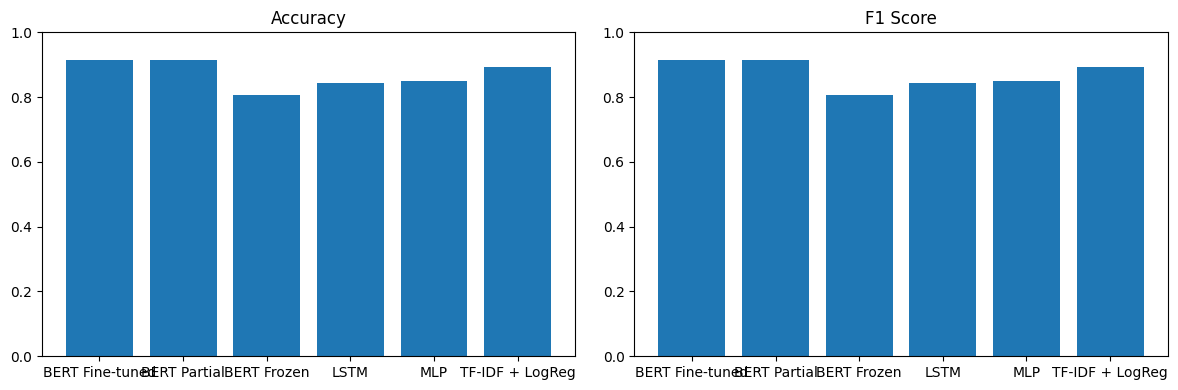

In [18]:
# Put all results in one table
results_df = pd.DataFrame({
    'Model': ['BERT Fine-tuned', 'BERT Partial', 'BERT Frozen', 'LSTM', 'MLP', 'TF-IDF + LogReg'],
    'Accuracy': [bert_results['accuracy'], partial_results['accuracy'], frozen_results['accuracy'], lstm_results['accuracy'], mlp_results['accuracy'], tfidf_results['accuracy']],
    'F1': [bert_results['f1'], partial_results['f1'], frozen_results['f1'], lstm_results['f1'], mlp_results['f1'], tfidf_results['f1']]
})
print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULTS_DIR}/final_comparison.csv', index=False)

# Plot the comparison
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(results_df['Model'], results_df['Accuracy'])
ax[0].set_title('Accuracy')
ax[0].set_ylim([0, 1])
ax[1].bar(results_df['Model'], results_df['F1'])
ax[1].set_title('F1 Score')
ax[1].set_ylim([0, 1])
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/comparison.png')
plt.show()

## 5) Comparative Analysis

The baselines answer different parts of the project question:

- `TF-IDF + Logistic Regression` is a classical bag-of-words baseline. It does not use neural representations or word order, but it is often strong for sentiment because sentiment words and short phrases are very predictive.
- `MLP` and `LSTM` are neural baselines trained from scratch. They use trainable embeddings but do not start from pretrained language knowledge.
- `BERT Frozen` tests whether pretrained BERT representations are useful without adapting the encoder to IMDb.
- `BERT Partial` tests a middle strategy: adapt only the last transformer layers while keeping most pretrained knowledge fixed.
- `BERT Fine-tuned` tests full task adaptation, where all BERT layers and the classifier head are trained on IMDb.

This lets us compare both baseline model families and fine-tuning strategies. If full BERT beats frozen BERT, the gain comes from task-specific adaptation rather than only from using pretrained representations. If partial BERT is close to full BERT, it suggests that adapting the upper layers is enough for much of the sentiment signal.

For data selection, we use a stratified train/validation split so the validation set keeps the positive/negative balance of IMDb. This makes model selection more reliable than slicing the dataset by order. For data augmentation, we did not add synthetic examples in the main experiment because naive text augmentation can change sentiment labels. Reasonable future options would be back-translation, synonym replacement with manual checks, or targeted augmentation of short/ambiguous reviews.

- Consider adding qualitative error analysis and experiments with other pre-trained models (RoBERTa, DistilBERT).

In [19]:
# Small summary for slides
comparison = results_df.sort_values('F1', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

scratch_models = ['MLP', 'LSTM']
best_scratch = results_df[results_df['Model'].isin(scratch_models)].sort_values('F1', ascending=False).iloc[0]
bert_ft_f1 = results_df.loc[results_df['Model'] == 'BERT Fine-tuned', 'F1'].iloc[0]
frozen_f1 = results_df.loc[results_df['Model'] == 'BERT Frozen', 'F1'].iloc[0]

print(f"\nFine-tuned BERT vs best scratch baseline ({best_scratch['Model']}): {bert_ft_f1 - best_scratch['F1']:+.4f} F1")
print(f"Fine-tuned BERT vs frozen BERT: {bert_ft_f1 - frozen_f1:+.4f} F1")

          Model  Accuracy       F1
BERT Fine-tuned   0.91516 0.915157
   BERT Partial   0.91372 0.913716
TF-IDF + LogReg   0.89372 0.893718
            MLP   0.85124 0.851192
           LSTM   0.84264 0.842078
    BERT Frozen   0.80512 0.805119

Fine-tuned BERT vs best scratch baseline (MLP): +0.0640 F1
Fine-tuned BERT vs frozen BERT: +0.1100 F1


## 6) Qualitative Error and OOD Analysis

The final metric table tells us how often each model is correct, but not why errors happen. Here we inspect examples misclassified by the fine-tuned BERT model and look for out-of-distribution or difficult cases: very long reviews, mixed sentiment, sarcasm/irony, noisy HTML formatting, plot-heavy reviews, and ambiguous labels.

For this project, OOD does not mean a completely different dataset. It means examples that are unlike simple sentiment statements and therefore stress the assumptions of the model and dataset.

In [20]:
# Mistakes from the fine-tuned BERT model
label_names = {0: 'Negative', 1: 'Positive'}
error_rows = []

for i, (pred, label) in enumerate(zip(bert_results['predictions'], bert_results['labels'])):
    if int(pred) == int(label):
        continue

    text = str(test_texts[i])
    words = text.split()
    error_rows.append({
        'index': i,
        'true_label': label_names[int(label)],
        'predicted_label': label_names[int(pred)],
        'num_words': len(words),
        'has_html': '<br' in text.lower(),
        'has_negation': any(w.lower().strip(".,!?;:'\"") in {'not', "n't", 'never', 'no'} for w in words),
        'preview': text[:700].replace('\n', ' ')
    })

errors_df = pd.DataFrame(error_rows)
print(f"Misclassified examples: {len(errors_df)} / {len(test_texts)}")
display(errors_df.head(10))

Misclassified examples: 2121 / 25000


,index,true_label,predicted_label,num_words,has_html,has_negation,preview
0,4,Negative,Positive,134,False,True,"First off let me say, If you haven't enjoyed a..."
1,18,Negative,Positive,249,True,True,"Ben, (Rupert Grint), is a deeply unhappy adole..."
2,20,Negative,Positive,173,False,True,Low budget horror movie. If you don't raise yo...
3,37,Negative,Positive,238,False,True,The only reason this movie is not given a 1 (a...
4,73,Negative,Positive,770,True,True,"1983's ""Frightmare"" is an odd little film. The..."
5,74,Negative,Positive,412,False,True,"I don't get it! The teenage leads in ""Horror S..."
6,86,Negative,Positive,465,True,True,The film opens with a cult leader attempting t...
7,88,Negative,Positive,542,True,True,This is a hard film to rate. While it truly de...
8,95,Negative,Positive,243,True,True,"This film seems well made, and more efforts sh..."
9,109,Negative,Positive,682,True,True,Bloody Birthday opens to a shot of Meadowvale ...


In [21]:
# Pull out some examples that are worth reading manually
long_errors = errors_df.sort_values('num_words', ascending=False).head(5)
html_errors = errors_df[errors_df['has_html']].head(5)
negation_errors = errors_df[errors_df['has_negation']].head(5)

print('Longest misclassified reviews:')
display(long_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

print('Misclassified reviews with HTML/noisy formatting:')
display(html_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

print('Misclassified reviews with negation cues:')
display(negation_errors[['index', 'true_label', 'predicted_label', 'num_words', 'preview']])

Longest misclassified reviews:


,index,true_label,predicted_label,num_words,preview
1356,16512,Positive,Negative,2125,"Back in the mid/late 80s, an OAV anime by titl..."
1340,16250,Positive,Negative,2108,"(Some spoilers included:)<br /><br />Although,..."
1899,22365,Positive,Negative,1167,'The Merchant of Venice' is one of Shakespeare...
647,8182,Negative,Positive,1090,I remember vacationing in Florida when this mo...
62,722,Negative,Positive,1005,"Last fall (of 2001), I took a film class that ..."


Misclassified reviews with HTML/noisy formatting:


,index,true_label,predicted_label,num_words,preview
1,18,Negative,Positive,249,"Ben, (Rupert Grint), is a deeply unhappy adole..."
4,73,Negative,Positive,770,"1983's ""Frightmare"" is an odd little film. The..."
6,86,Negative,Positive,465,The film opens with a cult leader attempting t...
7,88,Negative,Positive,542,This is a hard film to rate. While it truly de...
8,95,Negative,Positive,243,"This film seems well made, and more efforts sh..."


Misclassified reviews with negation cues:


,index,true_label,predicted_label,num_words,preview
0,4,Negative,Positive,134,"First off let me say, If you haven't enjoyed a..."
1,18,Negative,Positive,249,"Ben, (Rupert Grint), is a deeply unhappy adole..."
2,20,Negative,Positive,173,Low budget horror movie. If you don't raise yo...
3,37,Negative,Positive,238,The only reason this movie is not given a 1 (a...
4,73,Negative,Positive,770,"1983's ""Frightmare"" is an odd little film. The..."


In [22]:
# Save a few examples for the slides/report
error_sample = pd.concat([
    long_errors.assign(category='long_review_or_truncation'),
    html_errors.assign(category='html_or_formatting_noise'),
    negation_errors.assign(category='negation_or_complex_sentiment')
]).drop_duplicates(subset='index')

error_path = f'{RESULTS_DIR}/bert_finetuned/error_analysis_examples.csv'
error_sample.to_csv(error_path, index=False)
print(f'Saved qualitative error examples to {error_path}')

Saved qualitative error examples to ../results/bert_finetuned/error_analysis_examples.csv


### Qualitative Findings to Report

After running the cells above, inspect 3-5 examples and summarize them in the report/presentation. Useful categories are:

- **Long-review truncation:** IMDb reviews can be much longer than 256 tokens, so BERT may miss decisive sentiment late in the review.
- **Mixed sentiment:** Some reviews praise acting, visuals, or music while criticizing story or pacing. Binary labels hide this nuance.
- **Sarcasm and irony:** Positive words can express negative sentiment depending on tone.
- **Formatting/noise:** IMDb contains HTML breaks and informal writing, which can distract the model.
- **Ambiguous labels:** Some reviews are closer to neutral or mixed, but IMDb forces a positive/negative label.

These cases reveal weaknesses of both the dataset and the pretrained model. The dataset simplifies nuanced opinions into binary labels, while BERT can still struggle with sarcasm, long-range evidence, and sentiment cues outside the first 256 tokens.